# 03 Modeling Event Study
## 모델링

### Distributed Lag Model
정책 강도의 현재월과 지연월 계수를 함께 추정한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "outputs" / "tables").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def load_table(name: str) -> pd.DataFrame:
    return pd.read_csv(TABLE_DIR / name)

def show_saved_figure(fig, name: str) -> None:
    path = FIGURE_DIR / name
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))

In [2]:
dlm_equal = load_table("dlm_gap_equal.csv")
dlm_synth = load_table("dlm_gap_synth.csv")

def lag_coefficients(df: pd.DataFrame, spec: str, lag_length: int) -> pd.DataFrame:
    out = df[
        (df["spec"] == spec)
        & (df["lag_length"] == lag_length)
        & (df["term"].str.match(r"^policy_intensity_m_lag\d+$", na=False))
    ].copy()
    out["lag"] = out["term"].str.extract(r"lag(\d+)").astype(int)
    return out.sort_values("lag")

main_equal = lag_coefficients(dlm_equal, "D_price_tourism_month_fe", 3)
main_synth = lag_coefficients(dlm_synth, "D_price_tourism_month_fe", 3)

pd.concat(
    [
        main_equal.assign(comparator="equal"),
        main_synth.assign(comparator="synthetic"),
    ],
    ignore_index=True,
)[["comparator", "lag", "coef", "std_error", "ci_low", "ci_high", "p_value"]]

,comparator,lag,coef,std_error,ci_low,ci_high,p_value
0,equal,0,-0.0036,0.0325,-0.0673,0.0602,0.9128
1,equal,1,0.0440,0.0227,-0.0006,0.0885,0.0530
2,equal,2,0.0584,0.0325,-0.0052,0.1220,0.0721
3,equal,3,0.0679,0.0316,0.0059,0.1299,0.0318
4,synthetic,0,0.0046,0.0354,-0.0648,0.0740,0.8964
5,synthetic,1,0.0465,0.0247,-0.0019,0.0949,0.0596
6,synthetic,2,0.0697,0.0343,0.0024,0.1369,0.0423
7,synthetic,3,0.0781,0.0344,0.0106,0.1456,0.0234


D 사양은 가격과 관광 통제를 함께 넣어 정책 강도와 경기 회복 신호를 분리하려는 기준 모델이다.

### Lag Coefficients
정책 충격이 한 달에 끝나는지, 몇 달 뒤까지 남는지 확인한다.

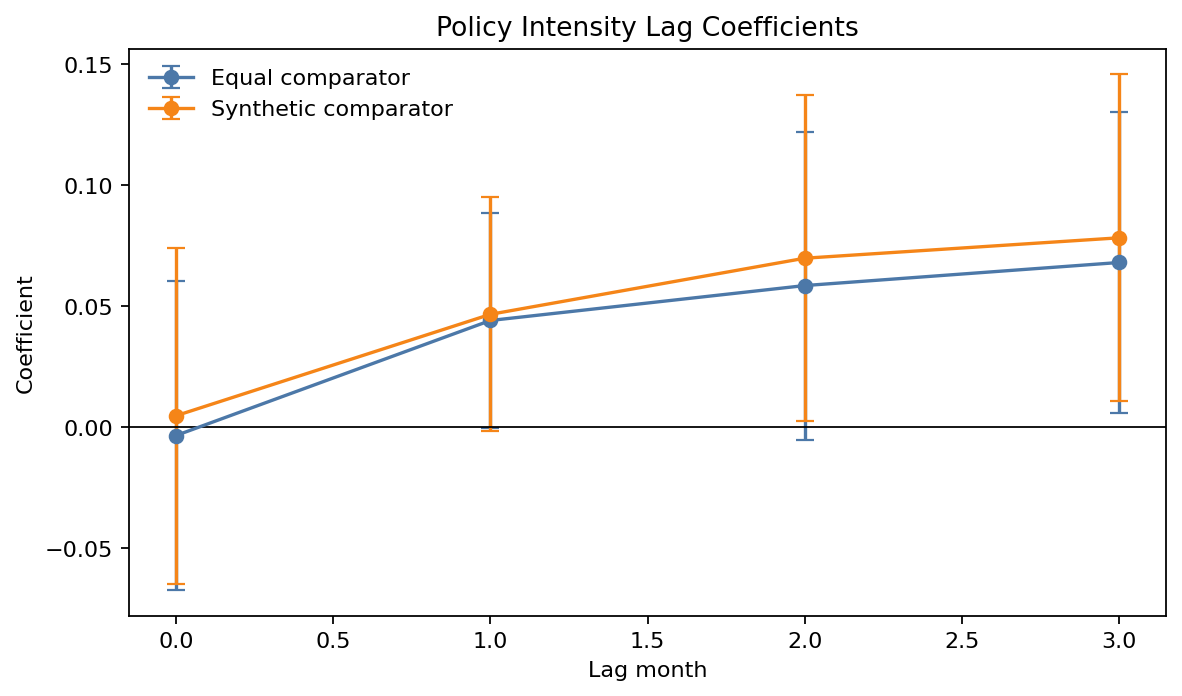

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for frame, label, color in [
    (main_equal, "Equal comparator", "#4C78A8"),
    (main_synth, "Synthetic comparator", "#F58518"),
]:
    ax.errorbar(
        frame["lag"],
        frame["coef"],
        yerr=[frame["coef"] - frame["ci_low"], frame["ci_high"] - frame["coef"]],
        marker="o",
        capsize=4,
        label=label,
        color=color,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Policy Intensity Lag Coefficients")
ax.set_xlabel("Lag month")
ax.set_ylabel("Coefficient")
ax.legend(frameon=False)
show_saved_figure(fig, "portfolio_dlm_lag_coefficients.png")

지연계수는 정책으로 오른 매출이 즉시 사라지는지, 종료 후에도 남는지를 판단하는 핵심 근거다.

### End-Centered Event Study
정책 종료 시점을 기준으로 종료 후 반응을 다시 정렬한다.

In [4]:
event_equal = load_table("end_centered_event_study_equal.csv")
event_synth = load_table("end_centered_event_study_synth.csv")

def event_terms(df: pd.DataFrame) -> pd.DataFrame:
    out = df[df["term"].str.startswith("event_")].copy()
    out["event_month"] = out["term"].str.replace("event_", "", regex=False).astype(int)
    return out.sort_values("event_month")

event_plot = pd.concat(
    [
        event_terms(event_equal).assign(comparator="equal"),
        event_terms(event_synth).assign(comparator="synthetic"),
    ],
    ignore_index=True,
)

event_plot[["comparator", "event_month", "coef", "std_error", "ci_low", "ci_high", "p_value"]].head(12)

,comparator,event_month,coef,std_error,ci_low,ci_high,p_value
0,equal,-3,0.0290,0.1511,-0.2672,0.3251,0.8480
1,equal,-3,0.0290,0.1511,-0.2672,0.3251,0.8480
2,equal,-3,0.0290,0.1511,-0.2672,0.3251,0.8480
3,equal,-3,0.0290,0.1511,-0.2672,0.3251,0.8480
4,equal,-2,-0.0489,0.0693,-0.1848,0.0870,0.4808
5,equal,-2,-0.0489,0.0693,-0.1848,0.0870,0.4808
6,equal,-2,-0.0489,0.0693,-0.1848,0.0870,0.4808
7,equal,-2,-0.0489,0.0693,-0.1848,0.0870,0.4808
8,equal,0,0.1347,0.0918,-0.0452,0.3145,0.1422
9,equal,0,0.1347,0.0918,-0.0452,0.3145,0.1422


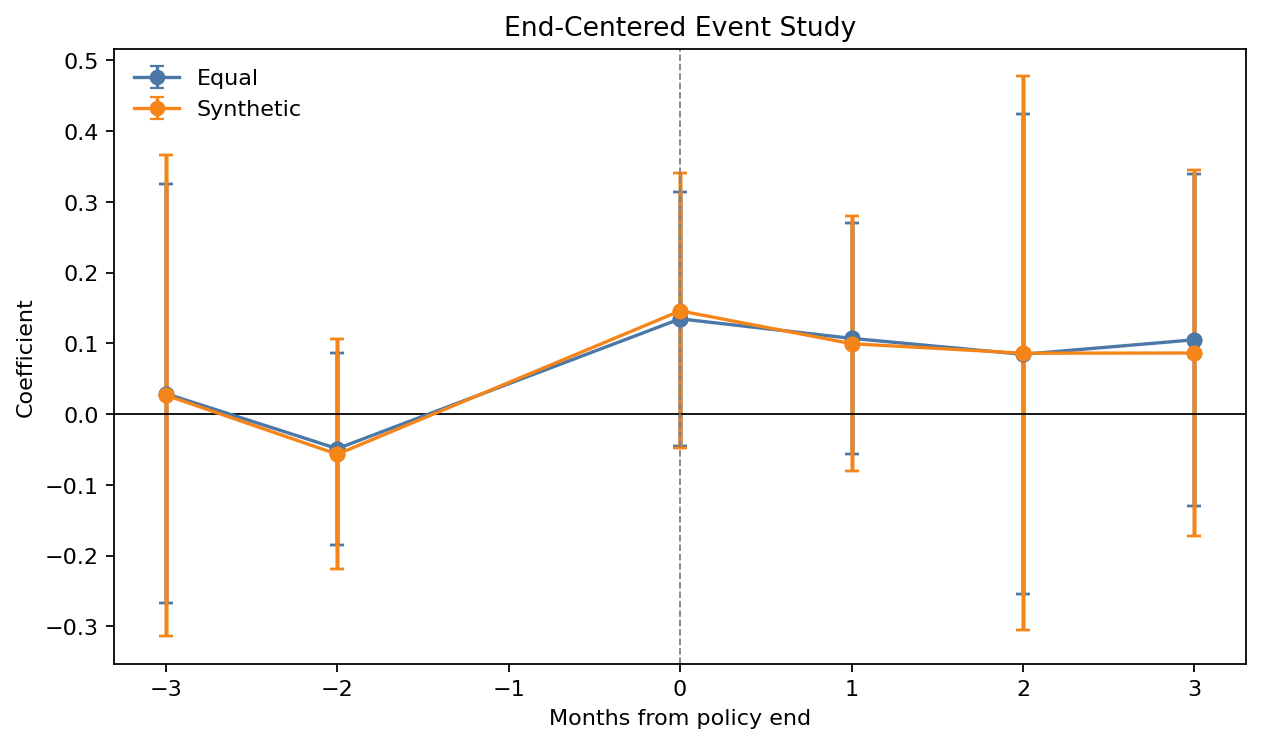

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.8))
for label, color in [("equal", "#4C78A8"), ("synthetic", "#F58518")]:
    frame = event_plot[event_plot["comparator"] == label]
    ax.errorbar(
        frame["event_month"],
        frame["coef"],
        yerr=[frame["coef"] - frame["ci_low"], frame["ci_high"] - frame["coef"]],
        marker="o",
        capsize=3,
        label=label.title(),
        color=color,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("End-Centered Event Study")
ax.set_xlabel("Months from policy end")
ax.set_ylabel("Coefficient")
ax.legend(frameon=False)
show_saved_figure(fig, "portfolio_end_centered_event_study.png")

종료 후 양의 계수가 남으면 단기 매출 상승이 바로 사라지지 않았다는 신호로 볼 수 있다.

### Stacked Policy Blocks
반복된 정책 블록을 한 번에 쌓아 평균 반응을 확인한다.

In [6]:
stacked = load_table("stacked_event_weighted_vs_unweighted.csv")
stacked_terms = stacked[stacked["term"].str.startswith("high_event_")].copy()
stacked_terms["event_month"] = stacked_terms["term"].str.replace("high_event_", "", regex=False).astype(int)

stacked_terms[["model", "event_month", "coef", "std_error", "ci_low", "ci_high", "p_value"]].head(14)

,model,event_month,coef,std_error,ci_low,ci_high,p_value
1,weighted,-3,0.0290,0.1586,-0.2818,0.3397,0.8551
2,weighted,-2,-0.0489,0.0751,-0.1961,0.0983,0.5150
3,weighted,0,0.1347,0.0980,-0.0573,0.3267,0.1692
4,weighted,1,0.1071,0.0889,-0.0672,0.2814,0.2285
5,weighted,2,0.0845,0.1813,-0.2708,0.4399,0.6411
6,weighted,3,0.1051,0.1264,-0.1427,0.3528,0.4059
50,unweighted,-3,0.0290,0.1551,-0.2750,0.3329,0.8519
51,unweighted,-2,-0.0489,0.0739,-0.1938,0.0961,0.5086
52,unweighted,0,0.1347,0.0962,-0.0538,0.3232,0.1614
53,unweighted,1,0.1071,0.0873,-0.0640,0.2782,0.2199


개별 정책 블록의 우연한 움직임이 아니라 반복 충격의 평균 패턴이 남는지 확인하는 단계다.